Logistic Regression gradient computation

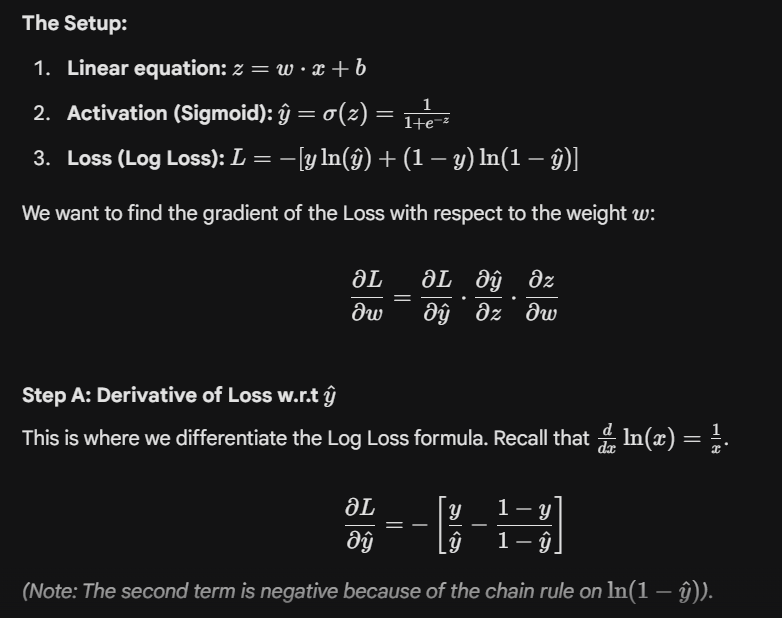
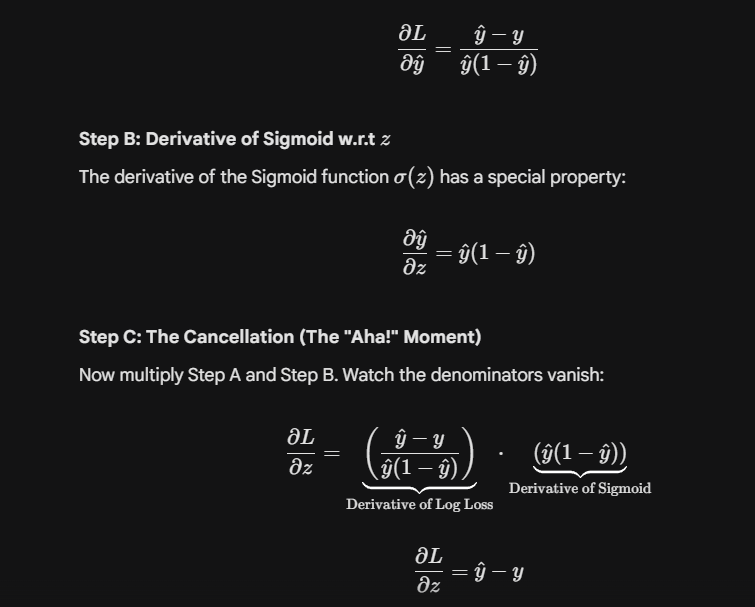
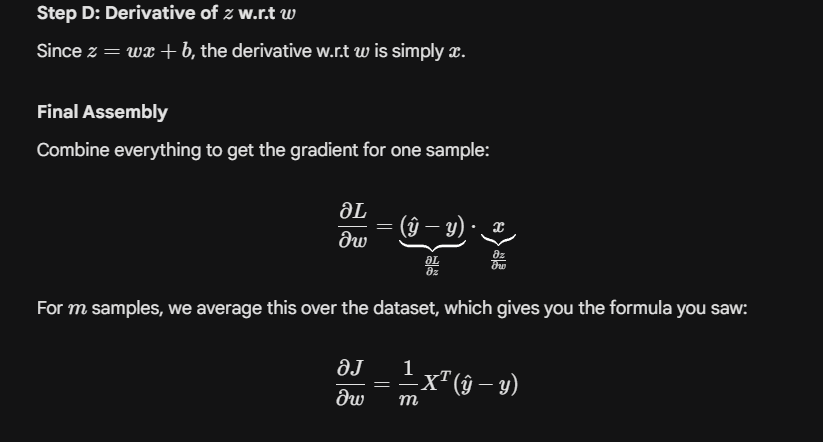
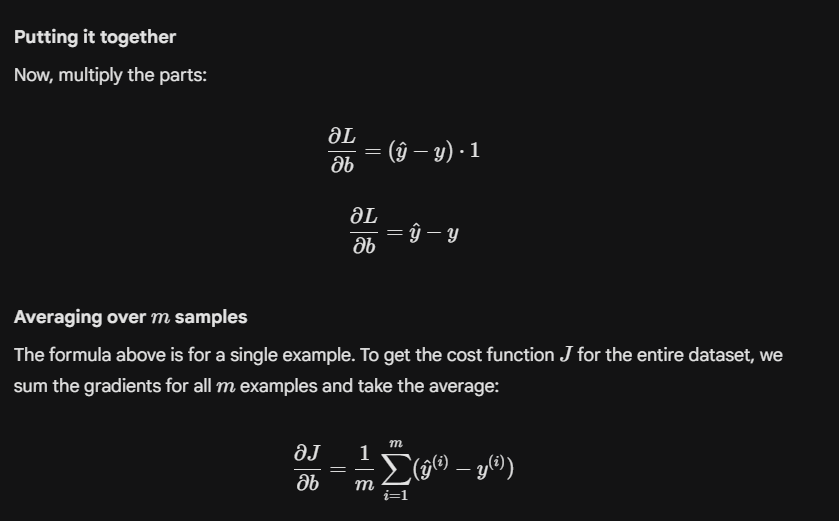

Data Loading and Observation

In [ ]:
import pandas as pd
from settings import TITANIC
df = pd.read_csv(TITANIC)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [5]:
df["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [6]:
df["Cabin"].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Start of Data preprocessing

In [8]:
# Drop columns not useful for modeling
df = df.drop(columns=['PassengerId', 'Name', 'Cabin', 'Ticket'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [9]:
from sklearn.model_selection import train_test_split
X = df.drop("Survived", axis=1)
y = df["Survived"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)



In [16]:

X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,3,female,21.0,0,0,7.6500,S
270,1,male,NaN,0,0,31.0000,S
860,3,male,41.0,2,0,14.1083,S
435,1,female,14.0,1,2,120.0000,S


In [10]:
from sklearn.impute import SimpleImputer
median_Imputer = SimpleImputer(strategy="median")
X_train['Age'] = median_Imputer.fit_transform(X_train[['Age']])
X_test['Age'] = median_Imputer.transform(X_test[['Age']])


In [11]:
# FIT on train
mode_imputer = SimpleImputer(strategy="most_frequent")
X_train['Embarked'] = mode_imputer.fit_transform(
    X_train[['Embarked']]
).ravel()

# TRANSFORM on test
X_test['Embarked'] = mode_imputer.transform(
    X_test[['Embarked']]
).ravel()


In [12]:
from sklearn.impute import SimpleImputer
median_Imputer = SimpleImputer(strategy="median")
X_train['Fare'] = median_Imputer.fit_transform(X_train[['Fare']])
X_test['Fare'] = median_Imputer.transform(X_test[['Fare']])


In [13]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,3,female,21.0,0,0,7.6500,S
270,1,male,28.0,0,0,31.0000,S
860,3,male,41.0,2,0,14.1083,S
435,1,female,14.0,1,2,120.0000,S


In [14]:
col = "Sex"
X_train[col] = X_train[col].astype(str).str.strip().str.lower().map({'male': 1, 'female': 0})
X_test[col] = X_test[col].astype(str).str.strip().str.lower().map({'male' : 1 , 'female' : 0})

In [15]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,1,45.5,0,0,28.5000,S
733,2,1,23.0,0,0,13.0000,S
382,3,1,32.0,0,0,7.9250,S
704,3,1,26.0,1,0,7.8542,S
813,3,0,6.0,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,3,0,21.0,0,0,7.6500,S
270,1,1,28.0,0,0,31.0000,S
860,3,1,41.0,2,0,14.1083,S
435,1,0,14.0,1,2,120.0000,S


In [17]:
print(X_train.dtypes)
print(X_train['Embarked'].head())


Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked        str
dtype: object
331    S
733    S
382    S
704    S
813    S
Name: Embarked, dtype: str


In [16]:
print(type(X_train))
print(X_train.columns)        # if X_train is a DataFrame
print(type(["Embarked"]))     # should be <class 'list'>

<class 'pandas.DataFrame'>
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='str')
<class 'list'>


In [18]:
embarked_dummies_train = pd.get_dummies(
    X_train['Embarked'],
    prefix='Embarked'
)
X_train = X_train.drop(columns=['Embarked'])
X_train = pd.concat([X_train, embarked_dummies_train], axis=1)
embarked_dummies_test = pd.get_dummies(
    X_test['Embarked'],
    prefix='Embarked'
)

X_test = X_test.drop(columns=['Embarked'])
X_test = pd.concat([X_test, embarked_dummies_test], axis=1)

# 🔑 critical step
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [19]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
331,1,1,45.5,0,0,28.5000,False,False,True
733,2,1,23.0,0,0,13.0000,False,False,True
382,3,1,32.0,0,0,7.9250,False,False,True
704,3,1,26.0,1,0,7.8542,False,False,True
813,3,0,6.0,4,2,31.2750,False,False,True
...,...,...,...,...,...,...,...,...,...
106,3,0,21.0,0,0,7.6500,False,False,True
270,1,1,28.0,0,0,31.0000,False,False,True
860,3,1,41.0,2,0,14.1083,False,False,True
435,1,0,14.0,1,2,120.0000,False,False,True


In [20]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
709,3,1,28.0,1,1,15.2458,True,False,False
439,2,1,31.0,0,0,10.5000,False,False,True
840,3,1,20.0,0,0,7.9250,False,False,True
720,2,0,6.0,0,1,33.0000,False,False,True
39,3,0,14.0,1,0,11.2417,True,False,False
...,...,...,...,...,...,...,...,...,...
433,3,1,17.0,0,0,7.1250,False,False,True
773,3,1,28.0,0,0,7.2250,True,False,False
25,3,0,38.0,1,5,31.3875,False,False,True
84,2,0,17.0,0,0,10.5000,False,False,True


In [21]:
# Create FamilySize feature and drop SibSp and Parch
X_train['FamilySize'] = X_train['SibSp'] + X_train['Parch'] + 1
X_test['FamilySize'] = X_test['SibSp'] + X_test['Parch'] + 1

# Drop the original columns
X_train = X_train.drop(columns=['SibSp', 'Parch'])
X_test = X_test.drop(columns=['SibSp', 'Parch'])

# Quick check
X_train.head()

,Pclass,Sex,Age,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
331,1,1,45.5,28.5000,False,False,True,1
733,2,1,23.0,13.0000,False,False,True,1
382,3,1,32.0,7.9250,False,False,True,1
704,3,1,26.0,7.8542,False,False,True,2
813,3,0,6.0,31.2750,False,False,True,7


In [22]:
from sklearn.preprocessing import StandardScaler
cols = ['Age' , 'Fare']
scaler = StandardScaler()
X_train[cols] = scaler.fit_transform(X_train[cols]) 
X_test[cols] = scaler.transform(X_test[cols])

In [23]:
X_train

,Pclass,Sex,Age,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
331,1,1,1.253641,-0.078684,False,False,True,1
733,2,1,-0.477284,-0.377145,False,False,True,1
382,3,1,0.215086,-0.474867,False,False,True,1
704,3,1,-0.246494,-0.476230,False,False,True,2
813,3,0,-1.785093,-0.025249,False,False,True,7
...,...,...,...,...,...,...,...,...
106,3,0,-0.631144,-0.480162,False,False,True,1
270,1,1,-0.092634,-0.030545,False,False,True,1
860,3,1,0.907456,-0.355804,False,False,True,3
435,1,0,-1.169653,1.683201,False,False,True,4


In [25]:
cols = ['Age','Fare']
print(X_train[cols].mean().round(6))   # ~0
print(X_train[cols].std().round(6))    # ~1
print(X_train[cols].describe().T)      # range, min/max
print((X_train[cols] < 0).sum())       # how many negatives

Age     0.0
Fare    0.0
dtype: float64
Age     1.000703
Fare    1.000703
dtype: float64
      count          mean       std       min       25%       50%       75%  \
Age   712.0  1.746418e-17  1.000703 -2.214363 -0.554214 -0.092634  0.445876   
Fare  712.0  5.363999e-17  1.000703 -0.627467 -0.474867 -0.349143 -0.040172   

           max  
Age   3.907725  
Fare  9.237724  
Age     451
Fare    547
dtype: int64


In [32]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

In [33]:
X_train.shape

(712, 8)

In [34]:
y_train.shape

(712,)

In [35]:
bool_cols = ["Embarked_C", "Embarked_Q", "Embarked_S"]

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)


In [36]:
X_train_np = X_train.values
X_test_np  = X_test.values

y_train_np = y_train.values.reshape(-1, 1)
y_test_np  = y_test.values.reshape(-1, 1)


In [42]:
X_train_np.shape

(712, 8)

In [44]:
y_train_np.shape

(712, 1)

In [38]:
import numpy as np

In [39]:
n = X_train_np.shape[1]

W = np.zeros((n, 1))  
b = 0.0               


In [40]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [45]:
def forward(X, W, b):
    z = np.dot(X, W) + b     
    y_hat = sigmoid(z)
    return y_hat


In [47]:
def compute_loss(y, y_hat):
    m = y.shape[0]
    epsilon = 1e-15 
    loss = -(1/m) * np.sum(
        y * np.log(y_hat + epsilon) +
        (1 - y) * np.log(1 - y_hat + epsilon)
    )
    return loss


In [48]:
def backward(X, y, y_hat):
    m = X.shape[0]
    
    dW = (1/m) * np.dot(X.T, (y_hat - y))   # (n, 1)
    db = (1/m) * np.sum(y_hat - y)          # scalar
    
    return dW, db


In [50]:
losses = []
def train(X, y, lr=0.01, epochs=1000):
    n = X.shape[1]
    W = np.zeros((n, 1))
    b = 0.0
    
    for i in range(epochs):
        y_hat = forward(X, W, b)
        loss = compute_loss(y, y_hat)
        losses.append(loss)
        dW, db = backward(X, y, y_hat)
        
        W -= lr * dW
        b -= lr * db
        
        if i % 100 == 0:
            print(f"Epoch {i}, Loss: {loss:.4f}")
    
    return W, b


In [51]:
W, b = train(X_train_np, y_train_np, lr=0.05, epochs=2000)


Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.5701
Epoch 200, Loss: 0.5416
Epoch 300, Loss: 0.5226
Epoch 400, Loss: 0.5093
Epoch 500, Loss: 0.4995
Epoch 600, Loss: 0.4921
Epoch 700, Loss: 0.4864
Epoch 800, Loss: 0.4818
Epoch 900, Loss: 0.4780
Epoch 1000, Loss: 0.4748
Epoch 1100, Loss: 0.4722
Epoch 1200, Loss: 0.4698
Epoch 1300, Loss: 0.4678
Epoch 1400, Loss: 0.4661
Epoch 1500, Loss: 0.4645
Epoch 1600, Loss: 0.4631
Epoch 1700, Loss: 0.4618
Epoch 1800, Loss: 0.4607
Epoch 1900, Loss: 0.4597


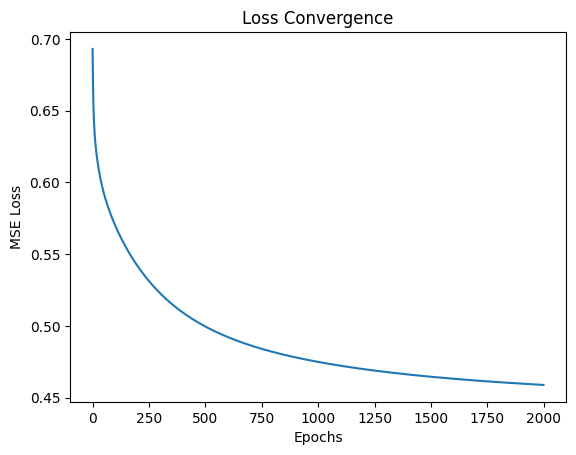

In [52]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss Convergence")
plt.show()


In [53]:
def predict(X, W, b, threshold=0.5):
    probs = forward(X, W, b)
    return (probs >= threshold).astype(int)


In [55]:
y_pred = predict(X_test_np, W, b)
accuracy = np.mean(y_pred == y_test_np)

print("Test Accuracy:", accuracy * 100)


Test Accuracy: 79.88826815642457
